# Z-test

In [ ]:
from scipy.stats import (
    norm, binom, expon
)
import numpy as numpy
from seaborn import distplot
from matplotlib import pyplot
import seaborn

import sys
sys.path.append('.')

In [ ]:
def inverse_plot_colorscheme():
    import cycler
    def invert(color_to_convert): 
        table = str.maketrans('0123456789abcdef', 'fedcba9876543210')
        return '#' + color_to_convert[1:].lower().translate(table).upper()
    update_dict = {}
    for key, value in pyplot.rcParams.items():
        if value == 'black':
            update_dict[key] = 'white'
        elif value == 'white':
            update_dict[key] = 'black'
    
    old_cycle = pyplot.rcParams['axes.prop_cycle']
    new_cycle = []
    for value in old_cycle:
        new_cycle.append({
            'color': invert(value['color'])
        })
    pyplot.rcParams.update(update_dict)
    pyplot.rcParams['axes.prop_cycle'] = cycler.Cycler(new_cycle)
    lec = pyplot.rcParams['legend.edgecolor']
    lec = str(1 - float(lec))
    pyplot.rcParams['legend.edgecolor'] = lec
inverse_plot_colorscheme()

Начиная с сегодняшней лекции мы будем анализировать средние значения выборок. Для начала зададимся вопросом: **зачем вообще их анализировать?**

Можно привести следующие реальные примеры из практики:

1. Прирост выручки.
* Если растет суммарное значение $\leftrightarrow$ растет среднее значение. Поэтому эту задачу можно переформулировать как рост среднего чека, или ARPU.
2. Увеличение числа покупок.
3. Уменьшение оттока пользователей.

Анализ среднего значения является одной из наиболее популярных задач в работе аналитика, поэтому очень важно уметь ее решать.

----------------------------------------------------

Далее, для вывода всех критериев нам потребуется **нормальное распределение**. Потому что именно *этому распределению подчиняется среднее выборок*.

Поэтому давайте посмотрим, что это вообще такое, как с ним работать в Python и какие у него есть свойства.

## 1 часть: нормальное распределение

Нормальное распределение $\mathcal{N}(\mu, \sigma^2)$ — непрерывное распределение, в котором плотность убывает с ростом расстояния от $\mu$ по экспоненте квадрата.

$$\mathcal{f}(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{1}{2}(\frac{x-\mu}{\sigma})^2}$$

,где
* $\mu$ — параметр сдвига: насколько центр сдвинут относительно 0
* $\sigma^2$ — параметр масштаба: насколько "пологий" будет график распределения.

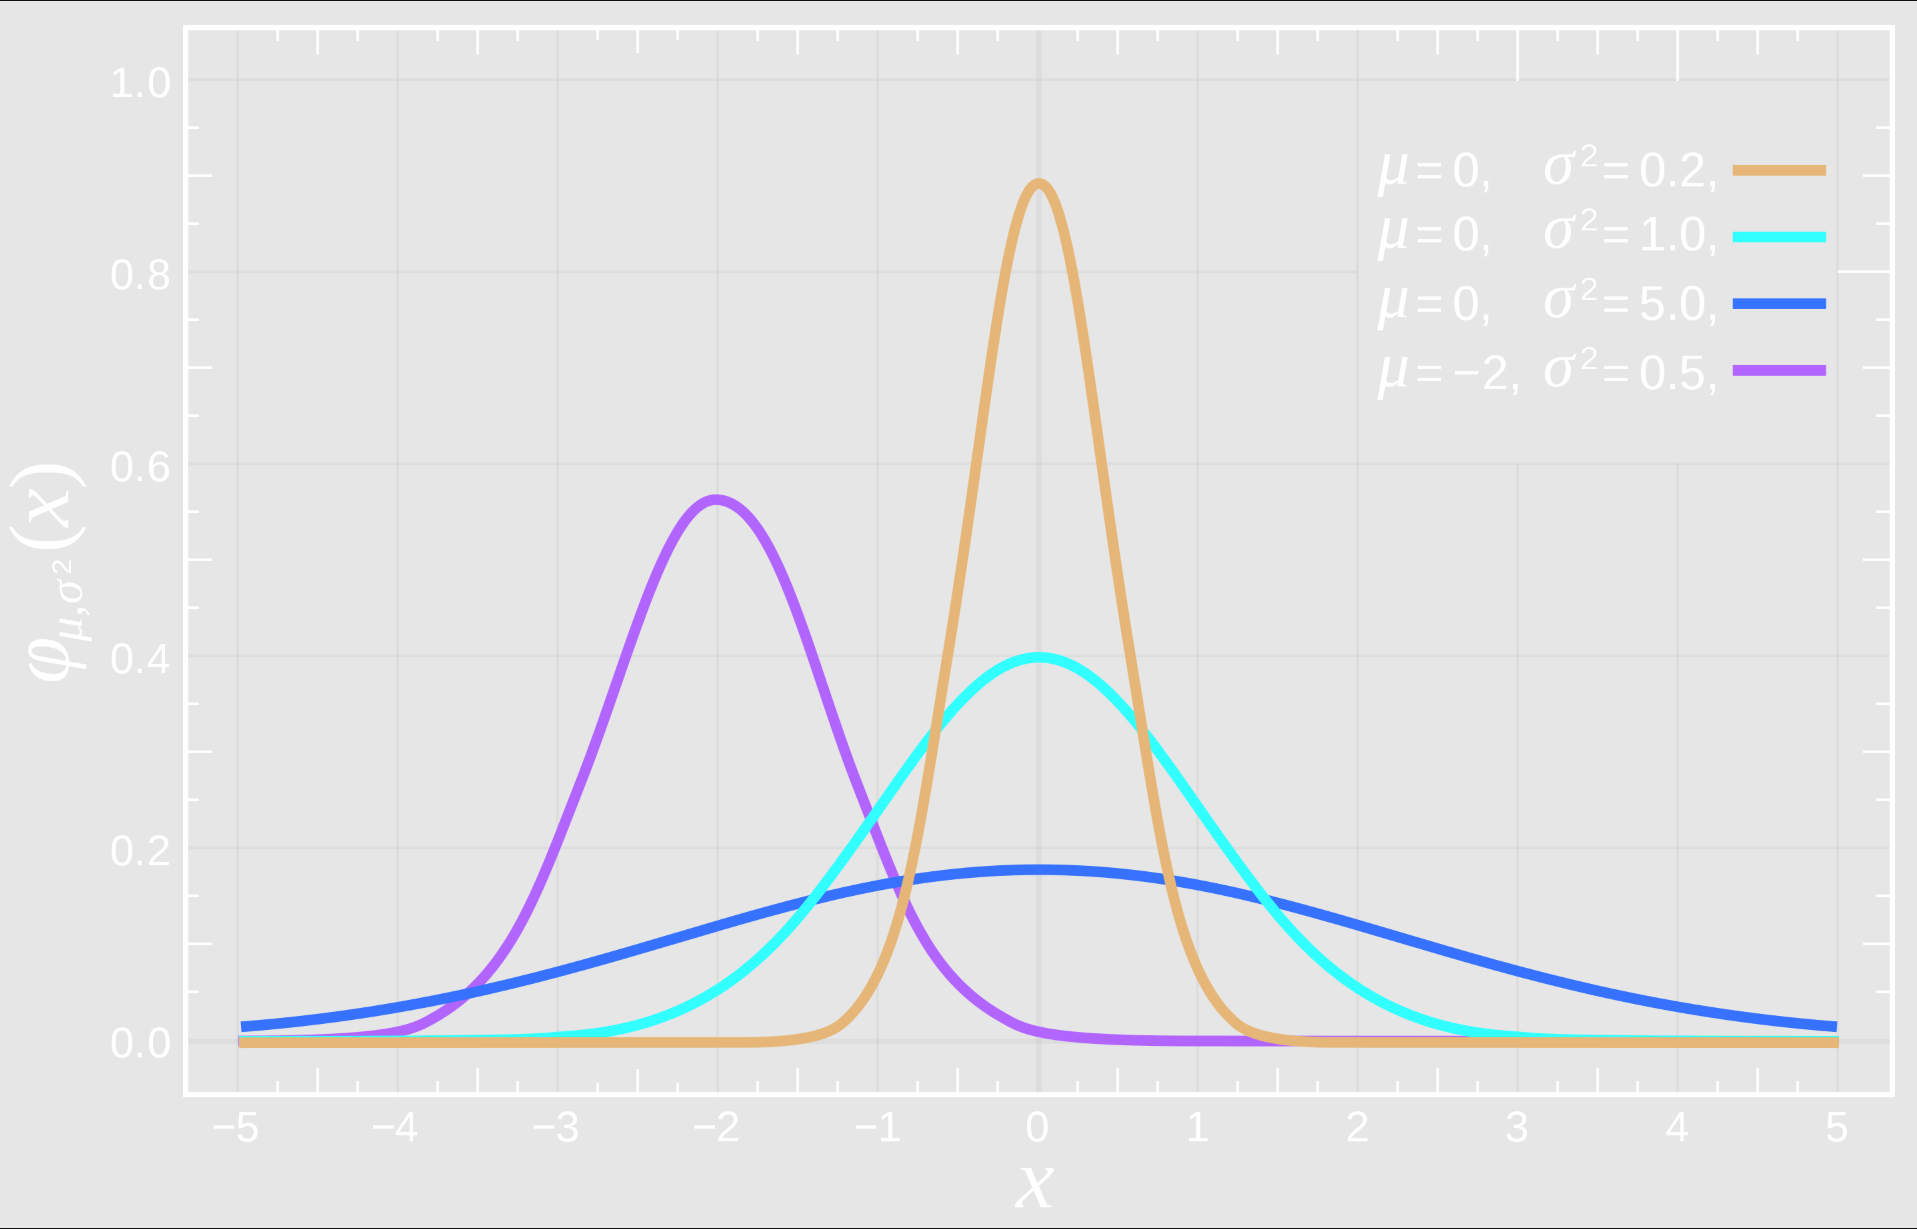

### Как пользоваться нормальным распределением в Python

Пусть мы хотим задать распределение $\mathcal{N}(\mu, \sigma^2)$. Для этого есть класс `norm`.

*Параметры инициализации*

* `loc` — это $\mu$
* `scale` — это $\sigma$, или стандартное отклонение. Не дисперсия!

Методы класса:

* `norm().cdf(x)` — функция распределения в точке x. $P(\xi \leq x)$
* `norm().ppf(q)` — получить квантиль распределения
* `norm().pdf(x)` — получить плотность распределения в точке x.

In [ ]:
# инициализация
stand_norm = norm(loc=0, scale=1)

In [ ]:
# cumulative distribution function
print(f"P(X <= 2)  = {stand_norm.cdf(x=2)}")
print(f"или так {norm(loc=0, scale=1).cdf(x=2)}")
# можно указывать массивы
print(f"[P(X <= 2), P(X <= -1)] = {stand_norm.cdf([2, -1])}")

P(X <= 2)  = 0.9772498680518208
или так 0.9772498680518208
[P(X <= 2), P(X <= -1)] = [0.97724987 0.15865525]


In [ ]:
# percent point function
print(f"quantile 0.975 = {stand_norm.ppf(0.975)}")

quantile 0.975 = 1.959963984540054


In [ ]:
# probability density function
print(f"pdf(0) = {stand_norm.pdf(0)}")

pdf(0) = 0.3989422804014327


Нарисуем график нормального распределения:

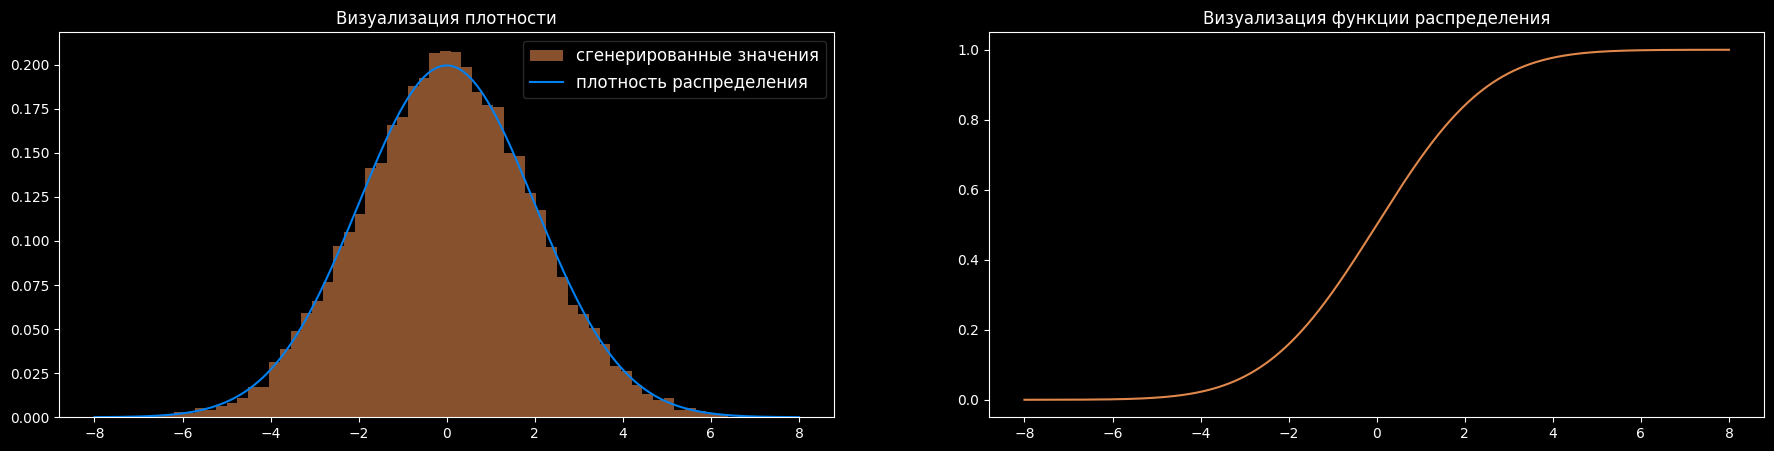

In [ ]:
check_distr = norm(loc=0, scale=2)
x = numpy.linspace(-8, 8, 1000) # расставит на равных расстояниях друг от друга 1000 точек от -8 до 8
pdf = check_distr.pdf(x)
cdf = check_distr.cdf(x)
sample = check_distr.rvs(10000)

pyplot.figure(figsize=(22, 5))

pyplot.subplot(1, 2, 1)
pyplot.title('Визуализация плотности', fontsize=12, color='white')
pyplot.hist(sample, bins='auto', density=True, alpha=0.6, label='сгенерированные значения') # rvs
pyplot.plot(x, pdf, label='плотность распределения') # pdf
pyplot.legend(fontsize=12)
###################################
pyplot.subplot(1, 2, 2)
pyplot.title('Визуализация функции распределения', fontsize=12)
pyplot.plot(x, cdf) # cdf
pyplot.show()

### Свойства нормального распределения

* $\xi_1 \sim \mathcal{N}(\mu_1, \sigma_1^2), \xi_2 \sim \mathcal{N}(\mu_2, \sigma_2^2) \Rightarrow \xi_1 + \xi_2 \sim \mathcal{N}(\mu_1+\mu_2, \sigma_1^2+\sigma_2^2)$,
* $\alpha\xi_1 \sim \mathcal{N}(\alpha\mu_1, \alpha^2\sigma_1^2)$

Покажем корректность этих вормул на практике:

Сначала проверим на примере формулу 1:

In [ ]:
# примеры
first_mean = 3
first_var = 4

second_mean = -1
second_var = 2

first_dist = norm(loc=first_mean, scale=numpy.sqrt(first_var))
second_dist = norm(loc=second_mean, scale=numpy.sqrt(second_var))
# Важно scale=numpy.sqrt(first_var + second_var)
checking_sum_distr = norm(loc=first_mean + second_mean, scale=numpy.sqrt(first_var + second_var))

1. Нагенерируем выборку из 1 и 2 распределений и просуммируем их.
2. Далее, построим эмпирическую плотность распределения и сравним ее с настоящей на графике.

C:\temp\volgin.a\ipykernel_32960\3977565118.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  distplot(sum_sample, label='Эмпирическое распределение')


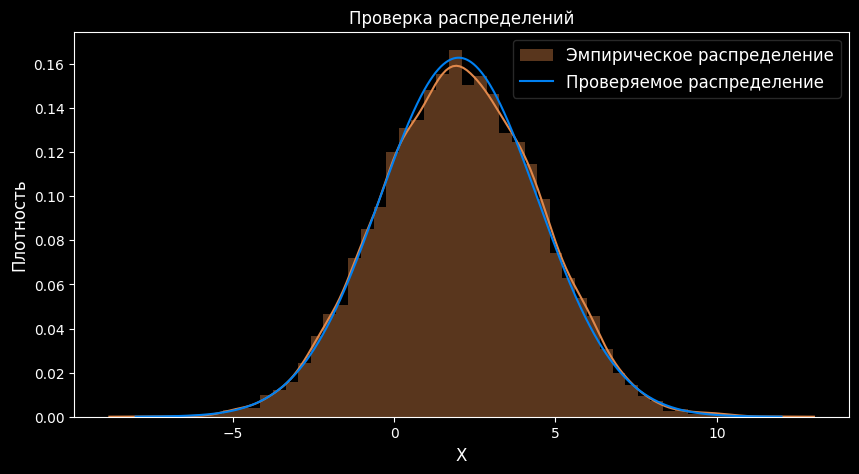

: 

In [ ]:
first_sample = first_dist.rvs(10000)
second_sample = second_dist.rvs(10000)
sum_sample = first_sample + second_sample

x = numpy.linspace(-8, 12, 1000)

pyplot.figure(figsize=(10, 5))
pyplot.title('Проверка распределений', fontsize=12)
# Эта функция строит как гисторгамму значений, так и эмпирическое распределение
distplot(sum_sample, label='Эмпирическое распределение')
pyplot.plot(x, checking_sum_distr.pdf(x), label='Проверяемое распределение')
pyplot.legend(fontsize=12)
pyplot.xlabel('X', fontsize=12)
pyplot.ylabel('Плотность', fontsize=12)
pyplot.show()

Видно, что распределения примерно совпали! А значит мы удостоверились, что формула верна.

Второе утверждение можно проверить таким же образом на практике.

## 2 часть: ЦПТ

Для начала вспомним теорему, которая является основополагающей теоремой для всех критериев, которые мы рассмотрим в ближайших лекциях.

Центральная предельная теорема

Формулировка теоремы

Пусть 
 — независимо одинаково распределенные случайные величины, у которых сущестуют мат. ожидание и дисперсия: 
 и 
. тогда 
 
 сходится по распределению к 
.

Что это значит на практике

Если случайные величины в эксперименте независимы и одинаково распределены и ваша выборка достаточно большая, то вы можете полагать, что
 

где 
 — мат. ожидание и дисперсия одного элемента выборки.

Дополнение

Случайные величины могут быть слабо зависимы друг от друга и слегка по-разному распределены. Центральная предельная теорема все еще будет верна.

Несмотря на ослабление условий, всегда держите в голове условия применимости ЦПТ: забыв про них и не проверив свой критерий, вы можете некорректно проанализировать свой AB-тест.

Визуализация ЦПТ
Чтобы лучше понимать, как работает ЦПТ, я предлагаю визуализировать теорему: посмотрим на распределение средних значений в разных выборках. Как мы это сделаем?

Чтобы посмотреть, что некоторая случайная величина из нормального распределения, нам нужна выборка этих случайных величин.
В данном случае нам нужна выборка статистик из ЦПТ. Поэтому нам нужно нагенерировать N выборок по M элементов в каждой.
По каждой выборке надо посчитать нормированное среднее по M элементам.
В итоге мы получим выборку из N элементов.
Она и должна быть из нормального распределения.